<a href="https://colab.research.google.com/github/elandler/repo-pruebas/blob/main/Ejercicio_M3_U2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 3 - Unidad 2: Análisis de Sentimiento

El objetivo de este notebook es comparar distintos enfoques para clasificar reseñas de Yelp como positivas o negativas.

Se aplican tres métodos:

1. Enfoque basado en léxicos.
2. TextBlob.
3. Modelo supervisado con TF-IDF + Regresión Logística.

Luego se evalúan los resultados mediante accuracy, precision, recall, F1-score y matriz de confusión.

In [40]:
# ==========================================
# Instalación de librerías
# ==========================================

!pip install kagglehub[pandas-datasets] textblob spacy -q
!python -m textblob.download_corpora -q

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


In [41]:
import pandas as pd
import numpy as np

import kagglehub
from kagglehub import KaggleDatasetAdapter

from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Carga del dataset

Se utiliza el dataset Yelp Reviews, compuesto por reseñas de usuarios y su calificación en estrellas. Para este ejercicio se utilizará la columna `text` como entrada y `stars` como variable objetivo.

In [42]:
# ==========================================
# Carga del dataset
# ==========================================

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "vivekhn/yelp-reviews",
    "yelp.csv"
)

df.head()

/tmp/ipykernel_602/2167787502.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'yelp-reviews' dataset.


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


## Análisis inicial del dataset

El dataset contiene reseñas de Yelp con una calificación en estrellas. Para simplificar el problema, se transforma la calificación en una variable binaria:

- 1 = reseña positiva, para calificaciones de 4 o 5 estrellas.
- 0 = reseña negativa, para calificaciones de 1 o 2 estrellas.

Las reseñas de 3 estrellas se eliminan porque pueden considerarse neutras.

In [43]:
df.info()

df.columns

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


(10000, 10)

In [44]:
# Preparación del dataset

df_sent = df[["text", "stars"]].dropna().copy()

# Eliminamos reseñas neutras de 3 estrellas
df_sent = df_sent[df_sent["stars"] != 3]

# Sentimiento real: 1 positivo, 0 negativo
df_sent["sentimiento_real"] = df_sent["stars"].apply(lambda x: 1 if x >= 4 else 0)

df_sent["sentimiento_real"].value_counts()

,count
sentimiento_real,
1,6863
0,1676


sentimiento_real
Positivo    6863
Negativo    1676
Name: count, dtype: int64


<Axes: title={'center': 'Distribución de clases'}, xlabel='sentimiento_real'>

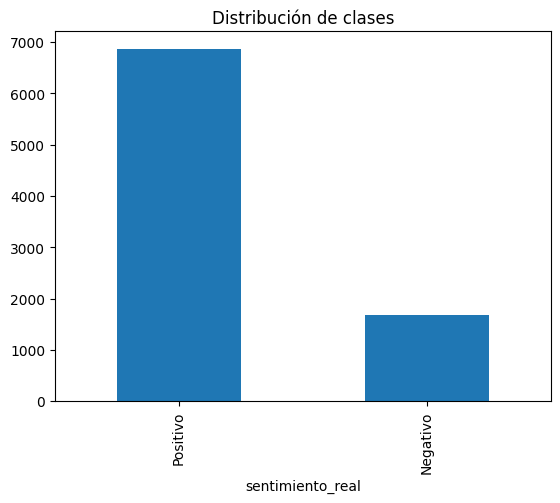

In [45]:
# Distribución de clases
distribucion = df_sent["sentimiento_real"].value_counts().rename(index={0: "Negativo", 1: "Positivo"})
print(distribucion)

distribucion.plot(kind="bar", title="Distribución de clases")

## Interpretación del balance de clases

Se observa la distribución entre reseñas positivas y negativas. Si una clase aparece con mucha más frecuencia que la otra, el modelo puede tender a favorecer la clase mayoritaria.

Por este motivo no se evalúa únicamente con accuracy. También se utilizan precision, recall y F1-score, que permiten analizar mejor el rendimiento cuando hay desbalance.

In [46]:
import re

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-zA-Z\s]", "", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df_sent["text_clean"] = df_sent["text"].apply(limpiar_texto)

df_sent[["text", "text_clean"]].head()

,text,text_clean
0,My wife took me here on my birthday for breakf...,my wife took me here on my birthday for breakf...
1,I have no idea why some people give bad review...,i have no idea why some people give bad review...
2,love the gyro plate. Rice is so good and I als...,love the gyro plate rice is so good and i also...
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",rosie dakota and i love chaparral dog park its...
4,General Manager Scott Petello is a good egg!!!...,general manager scott petello is a good egg no...


In [47]:
# División train/test

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_sent,
    test_size=0.25,
    random_state=42,
    stratify=df_sent["sentimiento_real"]
)

test_df = test_df.copy()

test_df.shape

(2135, 4)

## Método 1: Clasificación basada en léxicos

Este enfoque utiliza listas de palabras positivas y negativas. Si una reseña contiene más palabras positivas que negativas, se clasifica como positiva. En caso contrario, se clasifica como negativa.

Es un método simple e interpretable, pero tiene limitaciones: no captura ironía, contexto, negaciones complejas ni expresiones ambiguas.

In [48]:
# Método 1: enfoque basado en léxico

positive_words = {
    "excellent", "good", "great", "amazing", "perfect", "best", "love",
    "delicious", "friendly", "nice", "awesome", "wonderful", "fantastic",
    "recommend", "happy", "fresh", "clean", "fast", "favorite"
}

negative_words = {
    "bad", "terrible", "awful", "worst", "horrible", "poor", "slow",
    "dirty", "rude", "disappointed", "hate", "cold", "expensive",
    "bland", "disgusting", "never", "problem", "wrong", "waste"
}

def predecir_lexico(texto):
    texto = str(texto).lower()
    palabras = texto.split()

    pos = sum(1 for p in palabras if p.strip(".,!?;:()[]") in positive_words)
    neg = sum(1 for p in palabras if p.strip(".,!?;:()[]") in negative_words)

    return 1 if pos >= neg else 0

test_df["pred_lexico"] = test_df["text"].apply(predecir_lexico)

test_df[["text", "sentimiento_real", "pred_lexico"]].head()

,text,sentimiento_real,pred_lexico
7651,confirmed better than subway blimpie quiznos e...,1,1
6343,Spring Rolls - Great! Singapore Noodles - Gre...,1,1
7583,I'm so sad I didn't discover the Herb Box soon...,1,1
2683,"Sauce is my kind of place. Great, inexpensive...",1,1
3716,I have been a long time customer at this car w...,0,1


## Método 2: Clasificación con TextBlob

TextBlob calcula una polaridad para cada texto. Si la polaridad es mayor o igual a cero, la reseña se clasifica como positiva; si es menor a cero, se clasifica como negativa.

Este método es más flexible que un léxico manual, pero sigue teniendo limitaciones para comprender contexto profundo o expresiones propias de un dominio específico.

In [49]:
# Método 2: TextBlob

from textblob import TextBlob

def predecir_textblob(texto):
    polarity = TextBlob(str(texto)).sentiment.polarity
    return 1 if polarity >= 0 else 0

test_df["pred_textblob"] = test_df["text"].apply(predecir_textblob)

test_df[["text", "sentimiento_real", "pred_textblob"]].head()

,text,sentimiento_real,pred_textblob
7651,confirmed better than subway blimpie quiznos e...,1,1
6343,Spring Rolls - Great! Singapore Noodles - Gre...,1,1
7583,I'm so sad I didn't discover the Herb Box soon...,1,1
2683,"Sauce is my kind of place. Great, inexpensive...",1,1
3716,I have been a long time customer at this car w...,0,0


## Método 3: Modelo supervisado con TF-IDF y Regresión Logística

Además de los métodos anteriores, se entrena un modelo supervisado. Primero se transforma el texto en vectores numéricos mediante TF-IDF y luego se entrena una Regresión Logística.

Este enfoque aprende patrones desde los datos etiquetados y permite comparar su rendimiento contra los métodos no supervisados o basados en reglas.

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(train_df["text_clean"])
X_test = vectorizer.transform(test_df["text_clean"])

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, train_df["sentimiento_real"])

test_df["pred_logreg"] = modelo_lr.predict(X_test)

In [51]:
# Métricas

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def calcular_metricas(y_true, y_pred, modelo):
    return {
        "modelo": modelo,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

resultados = [
    calcular_metricas(test_df["sentimiento_real"], test_df["pred_lexico"], "Lexico"),
    calcular_metricas(test_df["sentimiento_real"], test_df["pred_textblob"], "TextBlob"),
    calcular_metricas(test_df["sentimiento_real"], test_df["pred_logreg"], "TF-IDF + Regresión Logística")
]

df_metricas = pd.DataFrame(resultados)
df_metricas

,modelo,accuracy,precision,recall,f1
0,Lexico,0.839344,0.848300,0.974359,0.906970
1,TextBlob,0.841218,0.850739,0.973193,0.907855
2,TF-IDF + Regresión Logística,0.886651,0.883854,0.988928,0.933443


## Comparación de resultados

La tabla permite comparar el rendimiento de los tres enfoques. El método basado en léxicos es el más simple, pero depende fuertemente de la calidad de las listas de palabras. TextBlob ofrece una clasificación automática basada en polaridad. El modelo supervisado con TF-IDF y Regresión Logística aprende directamente desde los datos etiquetados, por lo que puede adaptarse mejor al dataset.

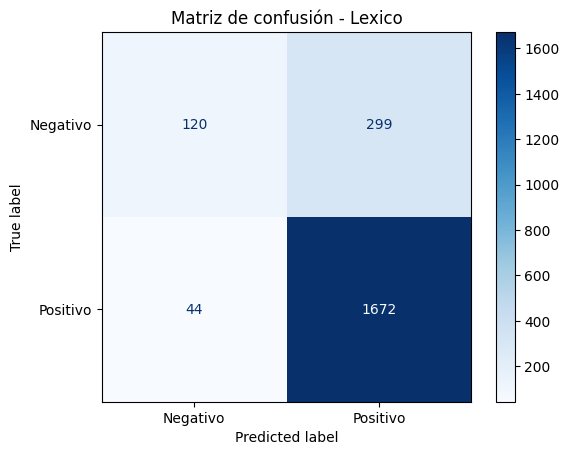

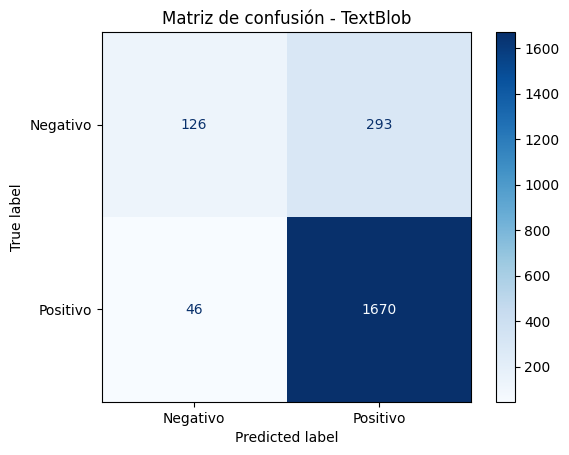

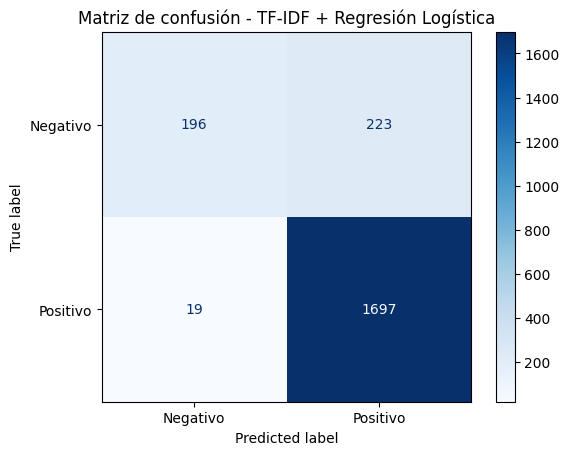

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

modelos = {
    "Lexico": test_df["pred_lexico"],
    "TextBlob": test_df["pred_textblob"],
    "TF-IDF + Regresión Logística": test_df["pred_logreg"]
}

for nombre, pred in modelos.items():
    cm = confusion_matrix(test_df["sentimiento_real"], pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo", "Positivo"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

## Interpretación de la matriz de confusión

La matriz de confusión permite observar qué tipos de errores comete cada método. Los falsos positivos representan reseñas negativas clasificadas como positivas. Los falsos negativos representan reseñas positivas clasificadas como negativas.

En análisis de sentimiento aplicado a clientes, estos errores son importantes porque pueden ocultar reclamos reales o generar una percepción incorrecta de satisfacción.

In [53]:
errores_logreg = test_df[test_df["sentimiento_real"] != test_df["pred_logreg"]]

errores_logreg[["text", "stars", "sentimiento_real", "pred_logreg"]].head(10)

,text,stars,sentimiento_real,pred_logreg
7874,I honestly wish I could give this place 0 star...,5,1,0
9839,Order was supposed to be ready 20 min ago...ye...,2,0,1
623,"I've only been here once, and for good reason....",2,0,1
5262,Made the mistake of coming here on opening day...,2,0,1
842,Boy is the name a temptation.Seriously :) I'l...,1,0,1
5947,"I went to Wokee Express tonight, per my friend...",2,0,1
3378,"Groupon rip-off. Small salad, three extremely ...",1,0,1
575,Here's the 1. 2. 3...\n\n1. Great Food. I love...,1,0,1
7930,Not exactly what I would call a great place to...,2,0,1
9076,This place is a bit scary. (And since it is a...,2,0,1


## Análisis de errores

Se observan algunos casos donde el modelo clasifica incorrectamente la polaridad. Estos errores pueden deberse a expresiones ambiguas, sarcasmo, contexto insuficiente o palabras con significado diferente según la oración.

El análisis de estos casos permite identificar oportunidades de mejora mediante un preprocesamiento más completo o el uso de modelos más avanzados.

In [54]:
# Reportes

print("Reporte - Método basado en léxico")
print(classification_report(
    test_df["sentimiento_real"],
    test_df["pred_lexico"],
    target_names=["Negativo", "Positivo"],
    zero_division=0
))

print("\nReporte - TextBlob")
print(classification_report(
    test_df["sentimiento_real"],
    test_df["pred_textblob"],
    target_names=["Negativo", "Positivo"],
    zero_division=0
))

Reporte - Método basado en léxico
              precision    recall  f1-score   support

    Negativo       0.73      0.29      0.41       419
    Positivo       0.85      0.97      0.91      1716

    accuracy                           0.84      2135
   macro avg       0.79      0.63      0.66      2135
weighted avg       0.83      0.84      0.81      2135


Reporte - TextBlob
              precision    recall  f1-score   support

    Negativo       0.73      0.30      0.43       419
    Positivo       0.85      0.97      0.91      1716

    accuracy                           0.84      2135
   macro avg       0.79      0.64      0.67      2135
weighted avg       0.83      0.84      0.81      2135



In [55]:
# Comparación final

df_metricas

,modelo,accuracy,precision,recall,f1
0,Lexico,0.839344,0.848300,0.974359,0.906970
1,TextBlob,0.841218,0.850739,0.973193,0.907855
2,TF-IDF + Regresión Logística,0.886651,0.883854,0.988928,0.933443


## Conclusiones

En este ejercicio se compararon tres enfoques para análisis de sentimiento sobre reseñas de Yelp.

El método basado en léxicos es rápido e interpretable, pero depende de listas manuales de palabras y no captura bien el contexto. TextBlob permite obtener una polaridad automática, aunque también puede fallar ante frases ambiguas o expresiones específicas del dominio.

En este ejercicio, el modelo supervisado basado en TF-IDF y Regresión Logística obtuvo el mejor desempeño entre los tres enfoques evaluados, mostrando una mayor capacidad para aprender patrones presentes en los datos etiquetados.

Como mejora futura, se podría aplicar un preprocesamiento más avanzado, probar otros modelos como Naive Bayes o SVM, ajustar hiperparámetros y evaluar modelos basados en embeddings o Transformers.

De los tres enfoques evaluados, el modelo supervisado basado en TF-IDF y Regresión Logística obtuvo el mejor desempeño general, ya que aprende patrones directamente a partir de los datos etiquetados. En cambio, el método léxico y TextBlob presentan limitaciones para interpretar correctamente el contexto y expresiones complejas.